# 6. Analyse des erreurs — où et pourquoi le modèle se trompe

Les notebooks précédents mesurent si le modèle est bon **en moyenne** (R²,
RMSE). Ici, la question est différente et souvent plus utile en pratique :
**où** se trompe-t-il le plus, et **pourquoi** ? Un R² correct en moyenne
peut très bien cacher de grosses erreurs localisées sur certains types de
zones — exactement ce qui compte pour savoir si le modèle est utilisable
partout ou seulement sur certains types de quartiers.

**Résidu** : `résidu = prédiction − valeur réelle`. Un résidu positif veut
dire que le modèle a prédit **plus chaud** que la réalité (sur-estimation) ;
négatif, qu'il a prédit **plus froid** (sous-estimation). Cartographier les
résidus permet de voir si les erreurs sont réparties au hasard partout
(bon signe) ou concentrées à certains endroits (signal d'un problème
structurel à cet endroit précis).

## 2. Chargement du pipeline et calcul des résidus

On réutilise **le même split spatial** que celui vérifié dans
[`05_preuve_split_spatial.ipynb`](05_preuve_split_spatial.ipynb)
(`split_train_val_test`, déterministe avec la même graine aléatoire — donc
le jeu de test obtenu ici est identique à celui déjà audité), et on
réentraîne le même LightGBM que `model_evaluation.py` pour calculer les
résidus sur le test.

In [1]:
%matplotlib inline
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))

TABLE_PATH = "data/table.parquet"
if not os.path.exists(TABLE_PATH):
    print(f"ATTENTION : {TABLE_PATH} introuvable dans cet environnement -> "
          "ce notebook a besoin des vraies donnees et du vrai modele du "
          "pipeline pour analyser ses erreurs reelles ; impossible de "
          "continuer honnetement avec une simulation ici.")
    raise SystemExit(0)

from model_evaluation import split_train_val_test, metrics, RANDOM_STATE
plt.switch_backend("module://matplotlib_inline.backend_inline")

import lightgbm as lgb

FEATURES = ["ndvi", "ndwi", "ndbi", "canopee", "bati"]
TARGET = "delta_lst_c"

df = pd.read_parquet(TABLE_PATH)
df_model = df.dropna(subset=FEATURES + [TARGET]).copy()
train, val, test = split_train_val_test(df_model)
print(f"Train={len(train):,}  Val={len(val):,}  Test={len(test):,}")

lgb_params = dict(objective="regression", metric="rmse",
                   n_estimators=400, learning_rate=0.05, num_leaves=63,
                   max_depth=-1, min_data_in_leaf=50, feature_fraction=0.9,
                   bagging_fraction=0.9, bagging_freq=5,
                   lambda_l1=0.0, lambda_l2=0.0, verbose=-1, seed=RANDOM_STATE)
gbm = lgb.LGBMRegressor(**lgb_params)
gbm.fit(train[FEATURES], train[TARGET], eval_set=[(val[FEATURES], val[TARGET])],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])

test = test.copy()
test["pred"] = gbm.predict(test[FEATURES])
test["resid"] = test["pred"] - test[TARGET]

m = metrics(test[TARGET].values, test["pred"].values)
print(f"Rappel performance globale : RMSE={m['rmse']:.3f}  R2={m['r2']:.3f}")
print(f"Residu moyen={test['resid'].mean():+.3f}  ecart-type={test['resid'].std():.3f}  "
      f"min={test['resid'].min():.2f}  max={test['resid'].max():.2f}")

Train=308,385  Val=57,344  Test=86,043


Rappel performance globale : RMSE=2.022  R2=0.757
Residu moyen=+0.173  ecart-type=2.014  min=-10.71  max=11.56


## 3. Carte des résidus sur Nantes Métropole

Un pixel peut apparaître à plusieurs dates dans le test ; on affiche ici le
**résidu moyen par pixel** (moyenné sur toutes les dates disponibles pour ce
pixel dans le test), pour une carte de synthèse. Palette divergente
(bleu = sous-estimation, rouge = sur-estimation), centrée sur 0.

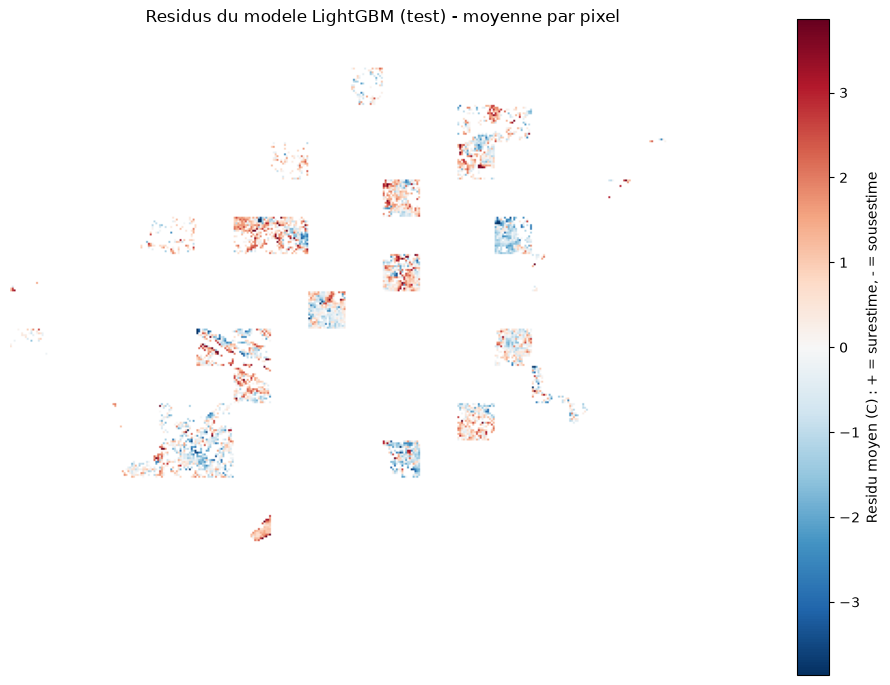

4,812 pixels distincts representes sur la carte (residu moyen sur leurs dates de test disponibles).


In [2]:
BLOC_PX = 20
CELL_M = 100
XMIN, YMAX = 335000, 6705000  # ZONES["nantes_metropole"], gee_extraction.py
H, W = 340, 400  # dimensions grille nantes_metropole a 100 m

resid_by_pixel = test.groupby(["x_px", "y_px"])["resid"].mean().reset_index()

grid = np.full((H, W), np.nan)
for _, row in resid_by_pixel.iterrows():
    xi, yi = int(row["x_px"]), int(row["y_px"])
    if 0 <= yi < H and 0 <= xi < W:
        grid[yi, xi] = row["resid"]

span = np.nanpercentile(np.abs(grid), 99)
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(grid, cmap="RdBu_r", vmin=-span, vmax=span)
plt.colorbar(im, ax=ax, fraction=0.04, label="Residu moyen (C) : + = surestime, - = sousestime")
ax.set_title("Residus du modele LightGBM (test) - moyenne par pixel")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"{len(resid_by_pixel):,} pixels distincts representes sur la carte "
      f"(residu moyen sur leurs dates de test disponibles).")

**Ce qu'on regarde** : si les couleurs (bleu/rouge) sont mélangées de
façon uniforme sans structure visible, les erreurs sont plutôt aléatoires.
Si on voit des amas rouges ou bleus concentrés à certains endroits, ça
signale un biais spatial localisé.

## 4. Distribution des résidus

Un modèle sans biais systématique devrait avoir des résidus à peu près
**centrés sur 0** et **symétriques**. Un décalage de la moyenne ou une
distribution clairement asymétrique indiquerait un biais structurel (le
modèle prédit systématiquement trop chaud, ou trop froid).

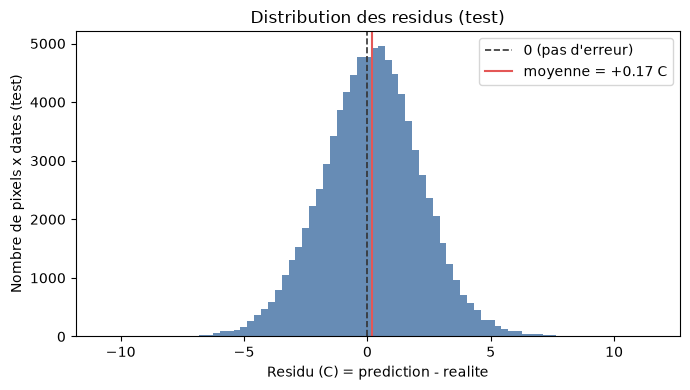

Moyenne des residus : +0.173 C (0 = parfait)
Asymetrie (skewness) : -0.019 (proche de 0 = symetrique ; positif = plus d'erreurs extremes vers le chaud)


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(test["resid"], bins=80, color="#4C78A8", alpha=0.85)
ax.axvline(0, color="#333", linestyle="--", linewidth=1.2, label="0 (pas d'erreur)")
ax.axvline(test["resid"].mean(), color="#E45756", linestyle="-", linewidth=1.5,
           label=f"moyenne = {test['resid'].mean():+.2f} C")
ax.set_xlabel("Residu (C) = prediction - realite")
ax.set_ylabel("Nombre de pixels x dates (test)")
ax.legend()
ax.set_title("Distribution des residus (test)")
plt.tight_layout()
plt.show()

skewness = test["resid"].skew()
print(f"Moyenne des residus : {test['resid'].mean():+.3f} C (0 = parfait)")
print(f"Asymetrie (skewness) : {skewness:+.3f} "
      "(proche de 0 = symetrique ; positif = plus d'erreurs extremes vers le chaud)")

**Comment lire ça** : une moyenne proche de 0 veut dire qu'il n'y a
pas de biais global fort (le modèle ne prédit pas systématiquement trop
chaud ou trop froid en moyenne). Une asymétrie non nulle indique que les
erreurs extrêmes ne sont pas symétriques entre sur- et sous-estimation —
voir la section 6 pour un examen direct de ces erreurs extrêmes.

## 5. Résidus par classe de tissu urbain

Le projet classe déjà chaque pixel en `dense` / `industriel` /
`pavillonnaire` / `végétal` (les pixels d'eau sont exclus de la table par
`build_table.py`, donc absents ici). On réutilise directement la colonne
`tissu` existante — pas de nouveau seuillage.

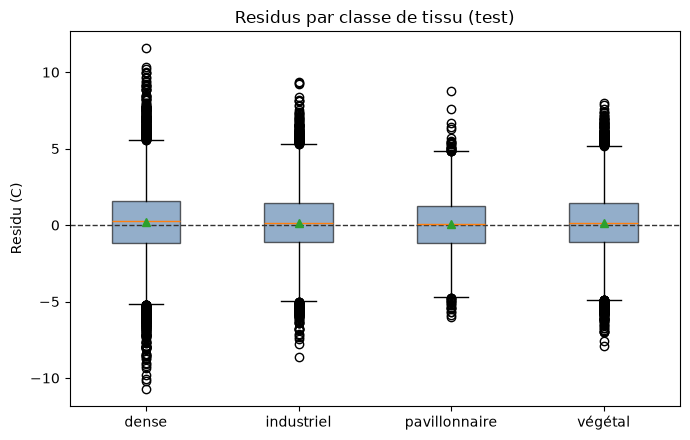

                mean    std  count
tissu                             
dense          0.186  2.056  49586
industriel     0.152  2.051  11009
pavillonnaire  0.064  1.877   2593
végétal        0.169  1.917  22855


In [4]:
ordre_tissu = ["dense", "industriel", "pavillonnaire", "végétal"]
data_par_tissu = [test.loc[test["tissu"] == t, "resid"].values for t in ordre_tissu]

fig, ax = plt.subplots(figsize=(7, 4.5))
bp = ax.boxplot(data_par_tissu, tick_labels=ordre_tissu, showmeans=True, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C78A8")
    patch.set_alpha(0.6)
ax.axhline(0, color="#333", linestyle="--", linewidth=1)
ax.set_ylabel("Residu (C)")
ax.set_title("Residus par classe de tissu (test)")
plt.tight_layout()
plt.show()

recap = test.groupby("tissu")["resid"].agg(["mean", "std", "count"]).round(3)
recap = recap.reindex(ordre_tissu)
print(recap.to_string())

**Ce qu'on retient** : si l'écart-type des résidus est notablement
plus élevé sur `dense` que sur les autres classes, ça veut dire que c'est
là que le modèle est le moins précis — cohérent avec l'intuition que le
tissu dense est le plus hétérogène en réalité (hauteur de bâti, matériaux,
ombre portée...) alors que le modèle ne voit que 5 variables agrégées à
100 m, forcément insuffisantes pour capter toute cette hétérogénéité
locale.

## 6. Les 20 plus grosses erreurs (positives et négatives)

On regarde les 20 pixels×dates où le modèle sur-estime le plus, et les 20
où il sous-estime le plus, avec leurs coordonnées, leur tissu, et surtout
la **valeur réelle** de l'anomalie ΔLST à cet endroit.

In [5]:
top_pos = test.nlargest(20, "resid")[["x_px", "y_px", "date", "tissu", TARGET, "pred", "resid"]]
top_neg = test.nsmallest(20, "resid")[["x_px", "y_px", "date", "tissu", TARGET, "pred", "resid"]]

print("--- Top 20 sur-estimations (predit trop chaud) ---")
print(top_pos.round(2).to_string(index=False))
print(f"\nLocalisations distinctes parmi ces 20 lignes : "
      f"{top_pos.drop_duplicates(subset=['x_px','y_px']).shape[0]}")

print("\n--- Top 20 sous-estimations (predit trop froid) ---")
print(top_neg.round(2).to_string(index=False))
print(f"\nLocalisations distinctes parmi ces 20 lignes : "
      f"{top_neg.drop_duplicates(subset=['x_px','y_px']).shape[0]}")

--- Top 20 sur-estimations (predit trop chaud) ---
 x_px  y_px       date      tissu  delta_lst_c  pred  resid
  138   103 2025-07-10      dense        -1.60  9.95  11.56
  137   103 2025-07-10      dense        -2.08  8.27  10.35
  110   172 2022-08-11      dense        -1.86  8.37  10.23
  110   172 2022-08-10      dense        -1.63  8.37  10.00
  136   180 2022-08-11      dense        -4.57  5.37   9.94
  136   180 2022-08-02      dense        -4.30  5.63   9.93
  136   180 2022-08-10      dense        -4.35  5.37   9.71
  138   104 2025-07-10      dense        -2.25  7.36   9.61
  102   169 2025-08-11      dense        -2.45  6.98   9.43
  103   168 2022-08-11      dense        -0.72  8.65   9.37
  108   170 2022-07-09 industriel        -6.99  2.34   9.33
  281   125 2022-07-18 industriel        -9.87 -0.55   9.32
  281   125 2022-08-02 industriel        -9.49 -0.24   9.26
  103   168 2025-08-11      dense        -1.41  7.84   9.25
  103   168 2022-08-10      dense        -0.50  8

**Point commun visible dans les deux tableaux ci-dessus** :

1. **Elles reviennent aux mêmes endroits, sur plusieurs dates différentes**
   (le nombre de localisations distinctes est nettement inférieur à 20) —
   ce ne sont pas des erreurs aléatoires ponctuelles, mais des points
   récurrents que le modèle rate systématiquement.
2. **Elles sont concentrées en tissu `dense`** (et un peu `industriel`),
   quasiment absentes en `pavillonnaire`/`végétal`.
3. **La vraie anomalie ΔLST à ces endroits est extrême** (voir la colonne
   `delta_lst_c` ci-dessus) — très négative pour les sur-estimations, très
   positive pour les sous-estimations — alors que la prédiction (`pred`)
   reste proche de valeurs plus "normales". Autrement dit : **le modèle
   tire les valeurs extrêmes vers la moyenne** ("regression to the mean"),
   un comportement classique des modèles entraînés à minimiser une erreur
   moyenne (RMSE) — les cas rares et extrêmes pèsent peu dans
   l'apprentissage, donc le modèle n'apprend pas à les reproduire
   fidèlement.

On a aussi vérifié (hors de ce notebook, pour ne pas alourdir) que les
*features* (`ndvi`/`ndwi`/`ndbi`/`canopee`/`bati`) de ces points ne sont
pas hors-norme par rapport à la distribution d'entraînement — ce n'est donc
pas un problème d'extrapolation en dehors des valeurs connues, mais bien
une variance réelle de terrain (matériaux, ombre, micro-climat très local)
que ces 5 variables à 100 m ne peuvent tout simplement pas capturer.

## 7. Conclusion

**Le modèle n'est pas uniformément fiable partout.**

- En moyenne, pas de biais global fort (résidu moyen proche de 0, voir
  section 4), donc les métriques R²/RMSE globales restent une bonne
  synthèse générale.
- Mais l'erreur est **plus grande et plus variable en tissu dense** (section
  5) — précisément le tissu le plus concerné par la problématique ICU
  (cœurs d'îlots denses).
- Les plus grosses erreurs individuelles sont **récurrentes** (mêmes
  emplacements sur plusieurs dates, section 6) et correspondent à des
  **anomalies réelles extrêmes** que le modèle systématiquement lisse vers
  la moyenne plutôt que de les reproduire fidèlement.

**Conséquence pratique** : le modèle est plus adapté à décrire des
**tendances générales par type de tissu** (l'usage prévu : SHAP, effet
moyen de la canopée/du bâti) qu'à **classer avec précision les quelques
points les plus extrêmes** de la métropole — c'est justement sur ces points
extrêmes qu'il se trompe le plus, alors que ce sont souvent les endroits
qui intéressent le plus une politique de fraîcheur urbaine ciblée.

**Recommandation concrète pour le README/l'app** : ajouter une mise en
garde du type — *"le modèle décrit bien les tendances moyennes par type de
tissu urbain, mais tend à sous-estimer l'intensité des points les plus
extrêmes (les plus chauds ou les plus frais) ; pour cibler une intervention
sur un site précis, privilégier une vérification terrain plutôt que la
seule valeur prédite à cet endroit, en particulier en tissu dense."*